# Trabalho

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

### Dados

In [141]:
semana = np.array([1., 2, 3, 4, 5, 6, 7])
novos_casos = np.array([1.8, 2.3, 1.5, 1.1, 2.4, 4.7, 7.9])

### Polinômio de quarto grau (mínimos quadrados)

Polinômio -> -2.529 + 7.349 x + -3.625 x^2 + 0.647 x^3 + -0.036 x^4
Erro -> 0.031


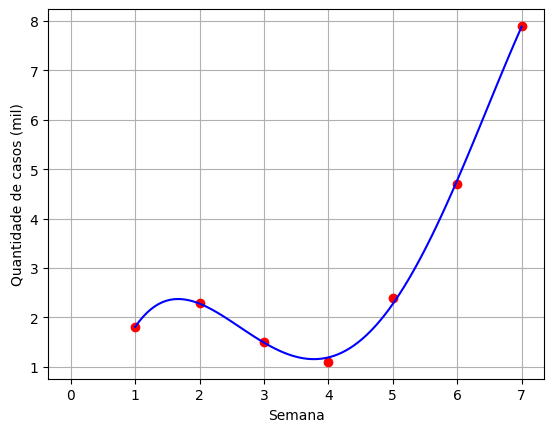

In [164]:
# grau
m = 4

# número de pontos
n = len(semana)

# número de coeficientes do polinômio
mn = m + 1

u = np.zeros((n, mn))

for i in range (0, mn):
    u[:, i] = semana ** i

# número de pontos para curva
N = 100

x = np.linspace(semana[0], semana[n-1], N)

G = np.zeros((mn, mn))
b = np.zeros(mn)

for i in range (0, mn):
    b[i] = np.sum(u[:, i] * novos_casos)

    for j in range (0, mn):
        G[i,j] = np.sum(u[:, i] * u[:, j])


# resolver o sistema linear
coefs = np.linalg.inv(G) @ b

print(f"Polinômio -> {coefs[0]:.03f} + {coefs[1]:.03f} x + {coefs[2]:.03f} x^2 + {coefs[3]:.03f} x^3 + {coefs[4]:.03f} x^4")

# erro de truncamento 
nos = u @ coefs
Q = np.sum((novos_casos[:] - nos) ** 2)
print(f"Erro -> {Q:0.3f}")

P = np.zeros((N, mn))

for i in range(0, mn):
    P[:, i] = x[:] ** (i)

y_aprox = P @ coefs

plt.plot(semana, novos_casos, 'ro', 4)
plt.plot(x, y_aprox, 'b-')
plt.xlabel("Semana")
plt.ylabel("Quantidade de casos (mil)")
plt.grid()
plt.show()

### Área da curva (integração)
Total acumulado de casos no período.

Área: 16.854545454720075


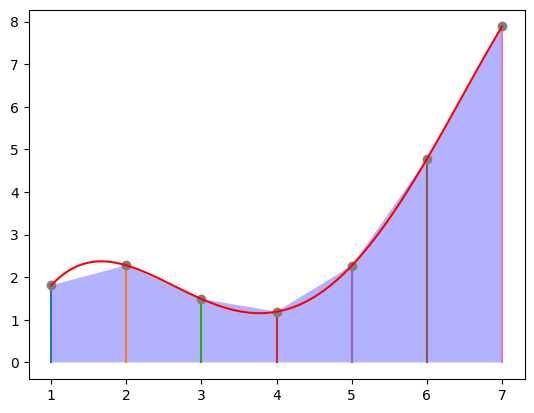

In [143]:
# Regra dos Trapézios

def funcao(x):
    return coefs[0] + coefs[1] * x + coefs[2] * (x**2) + coefs[3] * (x ** 3) + coefs[4] * (x ** 4) 

# intervalo de discretização
a = 1
b = 7
N = 6 # subintervalos
n = N + 1 # número de pontos

h = (b - a) / N

xi = np.linspace(a, b, n)

yi = funcao(xi)

soma = 0
for k in range (0, n):
    if k == 0 or k == n-1:
        soma += yi[k]

    else:
        soma += 2*yi[k]

I_trap = (h/2) * soma

print(f"Área: {I_trap}")

# para o gráfico
x_fino = np.linspace(a, b, 100)
y_fino = funcao(x_fino)

for k in range (0, N):
    xp = [xi[k], xi[k], xi[k+1], xi[k+1]]
    yp = [0, yi[k], yi[k+1], 0]
    plt.fill(xp, yp, 'b', alpha = 0.3)

for k in range (n):
    plt.plot([xi[k], xi[k]], [0, yi[k]])

plt.plot(xi, yi, 'o')
plt.plot(x_fino, y_fino, 'r-')
plt.show()


Área: 16.733333333507026


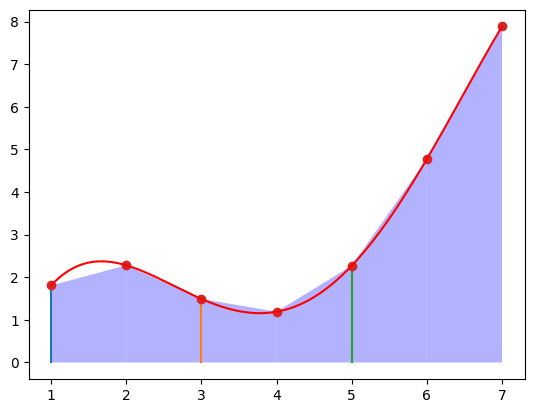

In [144]:
# Regra de Simpson (1/3)

def funcao(x):
    return coefs[0] + coefs[1] * x + coefs[2] * (x**2) + coefs[3] * (x ** 3) + coefs[4] * (x ** 4) 

# intervalo de discretização
a = 1
b = 7
N = 3 # subintervalos
n = 2*N + 1 # número de pontos

h = (b - a) / (2 * N)

xi = np.linspace(a, b, n)

yi = funcao(xi)

soma = 0
for k in range (0, n):
    if k == 0 or k == 2*N:
        soma += yi[k]

    elif k % 2 == 1:
        soma += 4 * yi[k]
    else:
        soma += 2 * yi[k]

I_simp_1_3 = (h/3) * soma

print(f"Área: {I_simp_1_3}")


# para o gráfico
x_fino = np.linspace(a, b, 500)
y_fino = funcao(x_fino)

for k in range (n-1):
    xp = [xi[k], xi[k], xi[k+1], xi[k+1]]
    yp = [0, yi[k], yi[k+1], 0]
    plt.fill(xp, yp, 'b', alpha = 0.3)

for k in range (0, 2 * N, 2):
    plt.plot([xi[k], xi[k]], [0, yi[k]])

plt.plot(xi, yi, 'o')
plt.plot(x_fino, y_fino, 'r-')
plt.show()

Integração analítica

$ N(t) = -2.529 + 7.349 x + -3.625 x^2 + 0.647 x^3 + -0.036 x^4 $

$ a = 1 $, $b = 7 $

- $ \int -2.529 dt  = -2.529 * (7-1) = -2.529 * 6 $

- $ \int 7.349 * t dt = 7.349 * \frac{1}{2} (7^2 - 1^2) = 7.349 * 48/2 $

- $ \int -3.625 * t^2 dt = -3.625 * \frac{1}{3} (7^3 - 1^3) $

- $ \int 0.647 * t^3 dt = 0.647 * \frac{1}{4} (7^4 - 1^4) $

- $ \int -0.036 * t^4 dt = -0.036 * \frac{1}{5} (7^5 - 1^5) $

$ \int N(t) dt = 16.76 $

### Comparando os resultados

Os resultados pela Regra do Trapézio e Simpson (1/3) foram similiares (16.85 e 16.73), enquanto que a integração analítica (resultado exato) foi diferente (16.76).

É importante acompanhar não somente os casos novos, mas também o total acumulado de casos para identificar em quais períodos a doença teve maior crescimento e decrescimento. A taxa semanal permite identificar se a doença está expandindo, recuando e visualizar a forma como a doença cresce ou morre (gráficos).

### Taxa de variação semanal (diferenciação)
Taxa de variação semanal no número de casos (quão rápido o surto acelerou ou desacelerou).

In [145]:
def diferenciacao_numerica(x0, func, dfunc, delta):
    length = len(delta)
    
    dfunc_centrada = np.zeros(length)
    
    erro_dfcentrada = np.zeros(length)


    for i in range(length):
        dfunc_centrada[i] = (func(x0 + delta[i]) - func(x0 - delta[i])) / (2 * delta[i])
        
        erro_dfcentrada[i] = abs(dfunc(x0) - dfunc_centrada[i]) / dfunc(x0)
    
    retorno = [dfunc_centrada, erro_dfcentrada]
    
    return retorno

def funcao(x):
    return coefs[0] + coefs[1] * x + coefs[2] * (x**2) + coefs[3] * (x ** 3) + coefs[4] * (x ** 4) 

f = funcao
df = lambda x: coefs[1] + 2 * coefs[2] * x + 3 * coefs[3] * (x ** 2) + 4 * coefs[4] * (x ** 3) 
delta = [0.2,0.1, 0.05, 0.025, 0.0125]

$ t = 2 $

In [146]:
t = 2

retorno_2 = diferenciacao_numerica(t,f,df,delta)
df_c_2 = retorno_2[0]
er_c_2 = retorno_2[1]


linhas_tabela = []
for i in range(len(delta)):
    linhas_tabela.append([
        f"{delta[i]:.4f}",
        f"{df_c_2[i]:.4f}", f"{er_c_2[i]:.4f}"
    ])

cabecalhos = [
    "Δt", 
    "Diferença Centrada", "Erro Relativo"
]

linhas_tabela.append([
        f"Derivada exata",
        f"{df(t):.4f}", f"{0:.4f}"
    ])

print(tabulate(linhas_tabela, headers=cabecalhos, stralign="center"))


      Δt          Diferença Centrada    Erro Relativo
--------------  --------------------  ---------------
    0.2000                   -0.5061          -0.0279
    0.1000                   -0.517           -0.007
    0.0500                   -0.5197          -0.0017
    0.0250                   -0.5204          -0.0004
    0.0125                   -0.5206          -0.0001
Derivada exata               -0.5206           0


$ t = 3 $

In [147]:
t = 3

retorno_2 = diferenciacao_numerica(t,f,df,delta)
df_c = retorno_2[0]
er_c = retorno_2[1]


linhas_tabela = []
for i in range(len(delta)):
    linhas_tabela.append([
        f"{delta[i]:.4f}",
        f"{df_c[i]:.4f}", f"{er_c[i]:.4f}"
    ])

cabecalhos = [
    "Δt", 
    "Diferença Centrada", "Erro Relativo"
]

linhas_tabela.append([
        f"Derivada exata",
        f"{df(t):.4f}", f"{0:.4f}"
    ])

print(tabulate(linhas_tabela, headers=cabecalhos, stralign="center"))


      Δt          Diferença Centrada    Erro Relativo
--------------  --------------------  ---------------
    0.2000                   -0.7558          -0.0115
    0.1000                   -0.7624          -0.0029
    0.0500                   -0.764           -0.0007
    0.0250                   -0.7644          -0.0002
    0.0125                   -0.7645          -0
Derivada exata               -0.7646           0


$ t = 4 $

In [148]:
t = 4

retorno_2 = diferenciacao_numerica(t,f,df,delta)
df_c = retorno_2[0]
er_c = retorno_2[1]


linhas_tabela = []
for i in range(len(delta)):
    linhas_tabela.append([
        f"{delta[i]:.4f}",
        f"{df_c[i]:.4f}", f"{er_c[i]:.4f}"
    ])

cabecalhos = [
    "Δt", 
    "Diferença Centrada", "Erro Relativo"
]

linhas_tabela.append([
        f"Derivada exata",
        f"{df(t):.4f}", f"{0:.4f}"
    ])

print(tabulate(linhas_tabela, headers=cabecalhos, stralign="center"))


      Δt          Diferença Centrada    Erro Relativo
--------------  --------------------  ---------------
    0.2000                    0.3158           0.0099
    0.1000                    0.3135           0.0025
    0.0500                    0.3129           0.0006
    0.0250                    0.3127           0.0002
    0.0125                    0.3127           0
Derivada exata                0.3127           0


$ t = 5 $

In [149]:
t = 5

retorno_2 = diferenciacao_numerica(t,f,df,delta)
df_c = retorno_2[0]
er_c = retorno_2[1]


linhas_tabela = []
for i in range(len(delta)):
    linhas_tabela.append([
        f"{delta[i]:.4f}",
        f"{df_c[i]:.4f}", f"{er_c[i]:.4f}"
    ])

cabecalhos = [
    "Δt", 
    "Diferença Centrada", "Erro Relativo"
]

linhas_tabela.append([
        f"Derivada exata",
        f"{df(t):.4f}", f"{0:.4f}"
    ])

print(tabulate(linhas_tabela, headers=cabecalhos, stralign="center"))


      Δt          Diferença Centrada    Erro Relativo
--------------  --------------------  ---------------
    0.2000                    1.8541           0.0014
    0.1000                    1.856            0.0003
    0.0500                    1.8565           0.0001
    0.0250                    1.8566           0
    0.0125                    1.8566           0
Derivada exata                1.8566           0


$ t = 6 $

In [150]:
t = 6

retorno_6 = diferenciacao_numerica(t,f,df,delta)
df_c_6 = retorno_6[0]
er_c_6 = retorno_6[1]

linhas_tabela = []
for i in range(len(delta)):
    linhas_tabela.append([
        f"{delta[i]:.4f}",
        f"{df_c_6[i]:.4f}", f"{er_c_6[i]:.4f}"
    ])


cabecalhos = [
    "Δt",
    "Diferença Centrada", "Erro Relativo"
]

linhas_tabela.append([
        f"Derivada exata",
        f"{df(6):.4f}", f"{0:.4f}"
    ])

print(tabulate(linhas_tabela, headers=cabecalhos, stralign="center"))

      Δt          Diferença Centrada    Erro Relativo
--------------  --------------------  ---------------
    0.2000                    3.0044           0.0027
    0.1000                    3.0106           0.0007
    0.0500                    3.0122           0.0002
    0.0250                    3.0126           0
    0.0125                    3.0127           0
Derivada exata                3.0127           0


In [172]:
d = np.empty(6)
d[0] = df(1)
d[1] = df(2)
d[2] = df(3)
d[3] = df(4)
d[4] = df(5)
d[5] = df(6)

s = semana

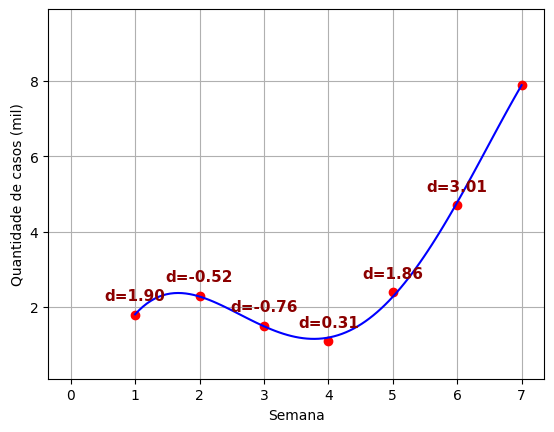

In [ ]:
plt.plot(semana, novos_casos, 'ro', 4)
plt.plot(x, y_aprox, 'b-')
plt.xlabel("Semana")
plt.ylabel("Quantidade de casos (mil)")
plt.grid()

offset = 0.3  

# coloca os valores das derivadas em cima de cada ponto
for s, c, deriv in zip(semana, novos_casos, d):
    plt.text(s, c + offset, f"d={deriv:.2f}", 
             ha='center',       
             va='bottom',       
             fontsize=11, 
             color='darkred', 
             fontweight='bold')

plt.ylim(min(novos_casos) - 1, max(novos_casos) + 2)

plt.show()

O comportamento do surto da epidemia em cada semana está totalmente relacionada com a derivada nos pontos. Sempre que a derivada tem valor positivo (ponto de inflexão positivo), o número de novos casos aumenta. Quando a derivada tem valor negativo (ponto de inflexão negativo), o número de novos casos cai.

### Finalizando
Com o uso de métodos computacionais, todo o cálculo é rapidamente realizado por meio de códigos (todos implementados em sala de aula), além disso, o Python permite gerar gráficos, como o gráfico do polinômio encontrado pelo método dos Mínimos Quadrados. Por isso, a ferramenta foi de extrema importância para o trabalho, possibilitando destacar fontes de erro numérico (cálculo à mão), mas também aumentar a precisão das casas decimais dos resultados.